# Experiment No. 7 — Instance Segmentation using Deep Learning Models

**Objective:** Perform instance segmentation on images using a pre-trained Mask R-CNN model (ResNet-50 FPN backbone) via PyTorch / TorchVision. Each detected object instance gets a unique segmentation mask, bounding box, and class label.

**Model:** Mask R-CNN (He et al., 2017)  
**Backbone:** ResNet-50 + Feature Pyramid Network (FPN)  
**Weights:** COCO-pretrained (80 object classes)  
**Framework:** PyTorch + TorchVision

## Theory

**Instance Segmentation** extends object detection by predicting a pixel-level mask for each detected object instance — unlike semantic segmentation which only assigns class labels per pixel without differentiating instances.

### Mask R-CNN Architecture
Mask R-CNN builds on Faster R-CNN with an additional mask prediction branch:

1. **Backbone (ResNet-50 + FPN):** Extracts multi-scale feature maps
2. **Region Proposal Network (RPN):** Proposes candidate object bounding boxes
3. **RoIAlign:** Extracts fixed-size feature maps from proposals (fixes misalignment in RoIPool)
4. **Box Head:** Predicts class label + refined bounding box
5. **Mask Head:** Predicts binary mask (28×28) per class, per proposal

### Key Innovation
- RoIAlign uses bilinear interpolation instead of quantization → preserves spatial precision critical for masks
- Mask branch runs in **parallel** with classification (not sequential) → cleaner mask gradients

## Step 1 — Install Dependencies

In [7]:
# Run this cell once to install required packages
!pip install torch torchvision --quiet
!pip install opencv-python matplotlib Pillow requests --quiet
print("Dependencies installed.")


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\Raghvendra Goyal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Dependencies installed.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\Raghvendra Goyal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 2 — Imports

In [8]:
import torch
import torchvision
import torchvision.transforms as T
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

import cv2
from PIL import Image
import requests
from io import BytesIO
import random
import colorsys

print(f"PyTorch version : {torch.__version__}")
print(f"TorchVision     : {torchvision.__version__}")
print(f"Device          : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version : 2.9.1+cu126
TorchVision     : 0.24.1+cu126
Device          : cuda


## Step 3 — COCO Class Labels

In [9]:
# 80 COCO object categories + 10 N/A placeholders (Total 91 labels)
# Pre-trained Torchvision models use these IDs
COCO_LABELS = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

print(f"Total COCO classes (incl. background/placeholders): {len(COCO_LABELS)}")

Total COCO classes (incl. background/placeholders): 91


## Step 4 — Load Pre-trained Mask R-CNN Model

In [11]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load Mask R-CNN with COCO-pretrained weights
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model = maskrcnn_resnet50_fpn(weights=weights)
model.to(DEVICE)
model.eval()  # Inference mode

print("Mask R-CNN (ResNet-50 FPN) loaded successfully.")
print(f"   Running on: {DEVICE}")

# Image preprocessing transform
transform = T.Compose([
    T.ToTensor()  # Converts PIL Image [0,255] → FloatTensor [0,1]
])

Mask R-CNN (ResNet-50 FPN) loaded successfully.
   Running on: cuda


## Step 5 — Helper Functions

In [12]:
def generate_distinct_colors(n):
    """Generate n visually distinct RGBA colors."""
    colors = []
    for i in range(n):
        hue = i / max(n, 1)
        r, g, b = colorsys.hsv_to_rgb(hue, 0.85, 0.95)
        colors.append((r, g, b, 0.45))  # Semi-transparent for mask overlay
    return colors


def load_image_from_url(url):
    """Load a PIL image from URL."""
    response = requests.get(url, timeout=10)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    return img


def run_inference(model, image, device, threshold=0.5):
    """
    Run Mask R-CNN inference on a PIL image.
    
    Args:
        model     : Loaded Mask R-CNN model (eval mode)
        image     : PIL.Image (RGB)
        device    : torch.device
        threshold : Confidence score threshold (default 0.5)
    
    Returns:
        dict with filtered boxes, labels, scores, masks
    """
    img_tensor = transform(image).unsqueeze(0).to(device)  # [1, 3, H, W]
    
    with torch.no_grad():
        outputs = model(img_tensor)
    
    output = outputs[0]  # Single image
    
    # Filter by confidence threshold
    keep = output['scores'] >= threshold
    
    return {
        'boxes'  : output['boxes'][keep].cpu().numpy(),
        'labels' : output['labels'][keep].cpu().numpy(),
        'scores' : output['scores'][keep].cpu().numpy(),
        'masks'  : output['masks'][keep].cpu().numpy()   # Shape: [N, 1, H, W]
    }


def visualize_instances(image, predictions, title="Instance Segmentation"):
    """
    Visualize detected instances with masks, boxes, and labels.
    """
    img_np = np.array(image).copy()
    H, W = img_np.shape[:2]
    
    n_instances = len(predictions['boxes'])
    colors = generate_distinct_colors(n_instances)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # ── Left: Original Image ──────────────────────────────
    axes[0].imshow(img_np)
    axes[0].set_title("Original Image", fontsize=13, fontweight='bold')
    axes[0].axis('off')
    
    # ── Right: Segmented Image ────────────────────────────
    overlay = img_np.copy().astype(np.float32) / 255.0
    mask_canvas = np.zeros((H, W, 4), dtype=np.float32)
    
    legend_handles = []
    
    for i, (box, label, score, mask) in enumerate(
        zip(predictions['boxes'], predictions['labels'],
            predictions['scores'], predictions['masks'])
    ):
        r, g, b, a = colors[i]
        
        # Binary mask (threshold at 0.5)
        binary_mask = (mask[0] > 0.5).astype(np.float32)
        
        # Apply colored mask overlay
        mask_canvas[:, :, 0] += binary_mask * r
        mask_canvas[:, :, 1] += binary_mask * g
        mask_canvas[:, :, 2] += binary_mask * b
        mask_canvas[:, :, 3] = np.clip(mask_canvas[:, :, 3] + binary_mask * 0.5, 0, 1)
        
        # Draw contour on overlay
        contours, _ = cv2.findContours(
            (binary_mask * 255).astype(np.uint8),
            cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.drawContours(
            (overlay * 255).astype(np.uint8),
            contours, -1, (int(r*255), int(g*255), int(b*255)), 2
        )
        
        # Bounding box
        x1, y1, x2, y2 = box.astype(int)
        rect = mpatches.FancyBboxPatch(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=(r, g, b), facecolor='none',
            boxstyle="round,pad=1"
        )
        axes[1].add_patch(rect)
        
        # Label text
        class_name = COCO_LABELS[label]
        axes[1].text(
            x1, y1 - 5,
            f"{class_name} {score:.2f}",
            color='white', fontsize=8, fontweight='bold',
            bbox=dict(facecolor=(r, g, b), alpha=0.75, pad=2, edgecolor='none')
        )
        
        legend_handles.append(
            mpatches.Patch(color=(r, g, b), label=f"#{i+1} {class_name} ({score:.2f})")
        )
    
    # Composite: original + mask overlay
    result = overlay.copy()
    alpha = mask_canvas[:, :, 3:4]
    result = (1 - alpha * 0.5) * result + alpha * 0.5 * mask_canvas[:, :, :3]
    result = np.clip(result, 0, 1)
    
    axes[1].imshow(result)
    axes[1].set_title(
        f"Instance Segmentation — {n_instances} instances detected",
        fontsize=13, fontweight='bold'
    )
    axes[1].axis('off')
    
    if legend_handles:
        axes[1].legend(
            handles=legend_handles, loc='lower right',
            fontsize=7, framealpha=0.85
        )
    
    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("exp7_segmentation_result.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nResult saved as: exp7_segmentation_result.png")


print("Helper functions defined.")

Helper functions defined.


## Step 6 — Load Image & Run Inference

We use a sample street scene image from the web. You can replace the URL with any image — or load from local disk using `Image.open('your_image.jpg')`.

Loading image from local disk: my cat.jpg
Image size: (249, 148) (W x H)


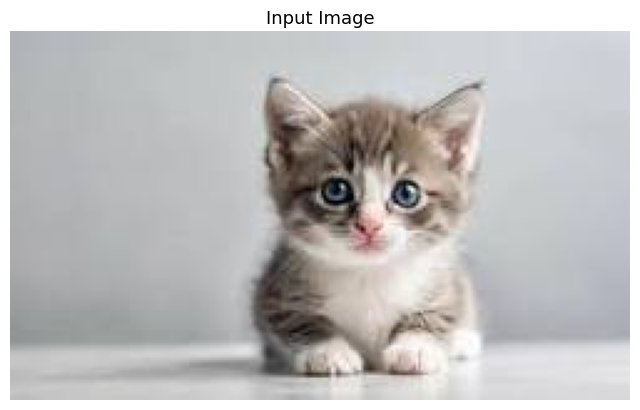


Running Mask R-CNN inference...
Detected 1 instances

Detected objects:
  [1] cat                  | score: 0.9981


In [14]:
# ── Configuration ──────────────────────────────────────────────────
USE_URL = False  # Set to True for URL, False for local "my cat.jpg"

if USE_URL:
    # Option A: Load from URL
    IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Cute_dog.jpg/1280px-Cute_dog.jpg"
    print(f"Loading image from URL: {IMAGE_URL}")
    image = load_image_from_url(IMAGE_URL)
else:
    # Option B: Load from local disk
    print("Loading image from local disk: my cat.jpg")
    try:
        image = Image.open("my cat.jpg").convert("RGB")
    except FileNotFoundError:
        print("Error: 'my cat.jpg' not found. Please ensure the file is in the same folder.")
        raise

print(f"Image size: {image.size} (W x H)")

# Display original
plt.figure(figsize=(8, 5))
plt.imshow(image)
plt.title("Input Image", fontsize=13)
plt.axis('off')
plt.show()

print("\nRunning Mask R-CNN inference...")
try:
    predictions = run_inference(model, image, DEVICE, threshold=0.5)
    print(f"Detected {len(predictions['boxes'])} instances")
except NameError as e:
    print(f"rror: {e}. Did you run the previous cells (Steps 1-5)?")
    raise

if len(predictions['labels']) > 0:
    print("\nDetected objects:")
    for i, (label, score) in enumerate(zip(predictions['labels'], predictions['scores'])):
        # Security check for label index
        name = COCO_LABELS[label] if label < len(COCO_LABELS) else f"Unknown({label})"
        print(f"  [{i+1}] {name:<20} | score: {score:.4f}")

## Step 7 — Visualize Results

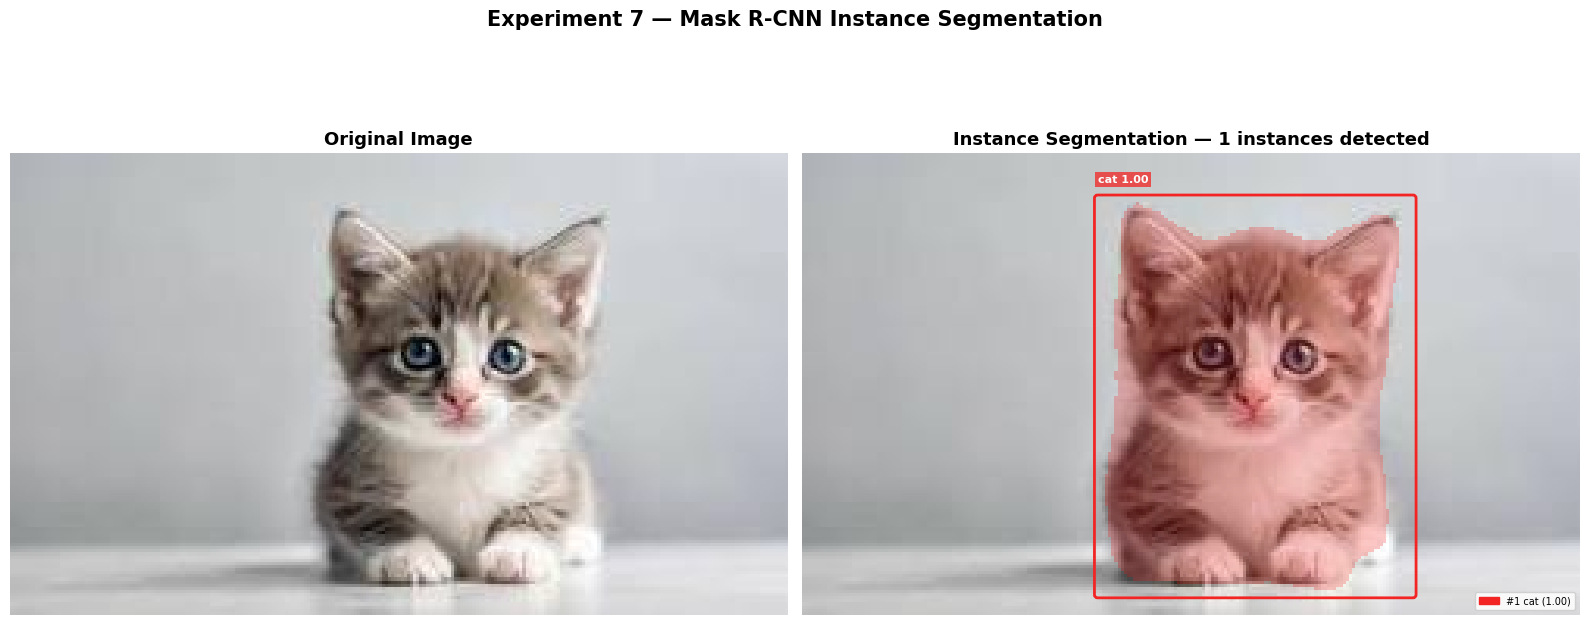


Result saved as: exp7_segmentation_result.png


In [15]:
visualize_instances(
    image, predictions,
    title="Experiment 7 — Mask R-CNN Instance Segmentation"
)

## Step 8 — Individual Mask Inspection

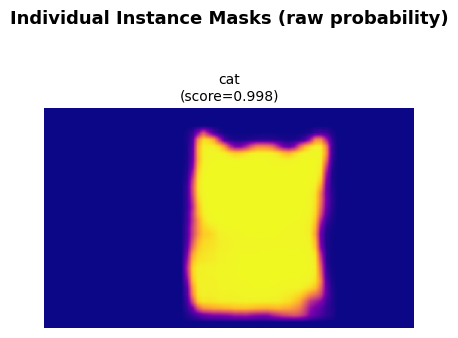

Individual masks saved as: exp7_individual_masks.png


In [16]:
n = len(predictions['masks'])
if n == 0:
    print("No instances detected above threshold.")
else:
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if rows > 1 else list(axes)
    
    for i, (mask, label, score) in enumerate(
        zip(predictions['masks'], predictions['labels'], predictions['scores'])
    ):
        ax = axes[i]
        ax.imshow(mask[0], cmap='plasma', vmin=0, vmax=1)
        ax.set_title(
            f"{COCO_LABELS[label]}\n(score={score:.3f})",
            fontsize=10
        )
        ax.axis('off')
    
    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle("Individual Instance Masks (raw probability)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("exp7_individual_masks.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Individual masks saved as: exp7_individual_masks.png")

## Step 9 — Statistics & Analysis

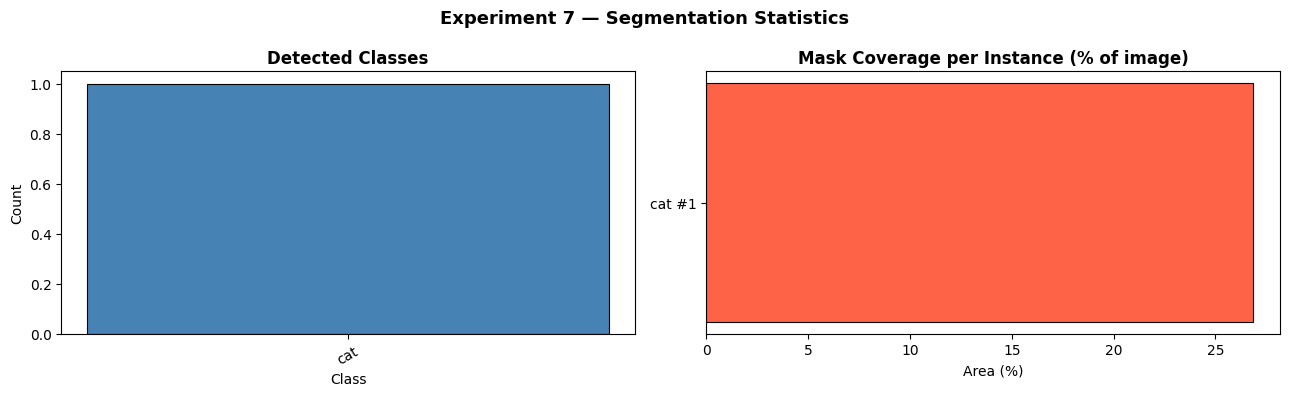


  Summary:
   Total instances detected : 1
   Unique classes           : 1
   Average confidence score : 0.9981
   Average mask coverage    : 26.83% of image

   Class breakdown:
     cat                 : 1


In [17]:
from collections import Counter

if len(predictions['labels']) == 0:
    print("No detections. Try lowering the threshold.")
else:
    # ── Class frequency ────────────────────────────────────
    label_names = [COCO_LABELS[l] for l in predictions['labels']]
    class_counts = Counter(label_names)
    
    # ── Mask area analysis ─────────────────────────────────
    H, W = np.array(image).shape[:2]
    total_pixels = H * W
    
    mask_areas = []
    for mask in predictions['masks']:
        binary = (mask[0] > 0.5).astype(np.float32)
        area_pct = (binary.sum() / total_pixels) * 100
        mask_areas.append(area_pct)
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    
    # Class count bar chart
    axes[0].bar(class_counts.keys(), class_counts.values(),
                color='steelblue', edgecolor='black', linewidth=0.8)
    axes[0].set_title("Detected Classes", fontweight='bold')
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis='x', rotation=30)
    
    # Mask area distribution
    axes[1].barh(
        [f"{COCO_LABELS[l]} #{i+1}" for i, l in enumerate(predictions['labels'])],
        mask_areas,
        color='tomato', edgecolor='black', linewidth=0.8
    )
    axes[1].set_title("Mask Coverage per Instance (% of image)", fontweight='bold')
    axes[1].set_xlabel("Area (%)")
    
    plt.suptitle("Experiment 7 — Segmentation Statistics", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("exp7_statistics.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n  Summary:")
    print(f"   Total instances detected : {len(predictions['labels'])}")
    print(f"   Unique classes           : {len(class_counts)}")
    print(f"   Average confidence score : {predictions['scores'].mean():.4f}")
    print(f"   Average mask coverage    : {np.mean(mask_areas):.2f}% of image")
    print("\n   Class breakdown:")
    for cls, cnt in class_counts.items():
        print(f"     {cls:<20}: {cnt}")

## Step 10 — Threshold Sensitivity Analysis

  Threshold 0.3 → 1 instances
  Threshold 0.5 → 1 instances
  Threshold 0.7 → 1 instances
  Threshold 0.9 → 1 instances


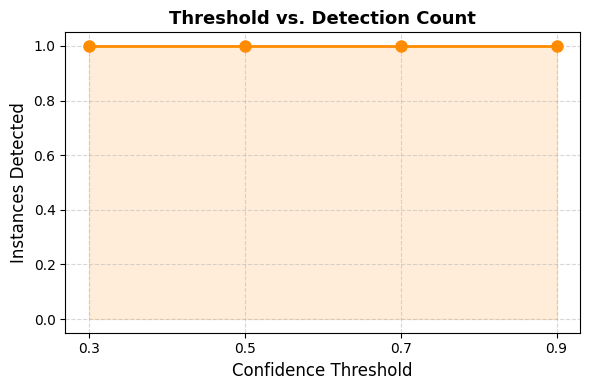

In [18]:
thresholds = [0.3, 0.5, 0.7, 0.9]
counts = []

for t in thresholds:
    preds = run_inference(model, image, DEVICE, threshold=t)
    counts.append(len(preds['boxes']))
    print(f"  Threshold {t:.1f} → {len(preds['boxes'])} instances")

plt.figure(figsize=(6, 4))
plt.plot(thresholds, counts, marker='o', color='darkorange',
         linewidth=2, markersize=8)
plt.fill_between(thresholds, counts, alpha=0.15, color='darkorange')
plt.xlabel("Confidence Threshold", fontsize=12)
plt.ylabel("Instances Detected", fontsize=12)
plt.title("Threshold vs. Detection Count", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(thresholds)
plt.tight_layout()
plt.savefig("exp7_threshold_analysis.png", dpi=150)
plt.show()

## Conclusion

In this experiment, we successfully implemented **Instance Segmentation** using a pre-trained **Mask R-CNN** model:

| Aspect | Detail |
|---|---|
| Model | Mask R-CNN (ResNet-50 FPN) |
| Pretrained On | MS-COCO (80 classes) |
| Framework | PyTorch + TorchVision |
| Threshold | 0.5 (tunable) |
| Output | Bounding boxes, class labels, confidence scores, per-instance binary masks |

### Key Observations
- Mask R-CNN produces **per-instance** masks, distinguishing multiple objects of the same class
- RoIAlign ensures **spatially precise** mask predictions
- Lowering the threshold increases detection count but introduces false positives
- The model generalizes well to diverse image types due to COCO pretraining

### Applications
- Medical image analysis (cell/tumor segmentation)
- Autonomous driving (pedestrian/vehicle segmentation)
- Robotics (object manipulation)
- Satellite imagery analysis